In [1]:
import numpy as np
from scipy.interpolate import interp1d
from astropy.time import Time

In [2]:
import matplotlib
import matplotlib.pyplot as plt
fs= 9
matplotlib.rcParams['font.size']=fs
ms = 6
matplotlib.rcParams['lines.markersize']=ms

In [3]:
from load_specfiles import load_tde_specfiles, bin_spec

In [4]:
def custom_ax(ax, xmax = 800, ymax = 8):
    ax.tick_params(which = 'major', length = 4, top=True, direction = "in", right = True)
    ax.tick_params(which = 'minor', length = 2, top=True, direction = "in", right = True)
    
    xmajor = 1000
    xminor = 100
    ymajor = 1
    yminor = 0.2
    ax.yaxis.set_major_locator(plt.MultipleLocator(ymajor))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(yminor))
    ax.xaxis.set_major_locator(plt.MultipleLocator(xmajor))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(xminor))
    
    ax.set_xlabel('Rest-frame Wavelength ('+r'$\rm \AA$'+')', fontsize = fs+1)
    ax.set_ylabel("Scaled "+r'$f_{\lambda}$'+"+offset", fontsize = fs+1)
    plt.xticks(fontsize= fs+1) 
    plt.yticks(fontsize= fs+1) 

In [5]:
def plot_source():
    name = "ZTF24aapvieu"
    dt = load_tde_specfiles(names = [name], skip_sdss = False)
    
    subdt = dt[name]
    z = 0.192
    spoff = subdt["off"]
    tref = 60460.24495 
    
    keys = list(subdt.keys())
    keys = np.array(keys)
    ix = np.array([x[:2]=="sp" for x in keys])
    keys = keys[ix]
    nsp = len(keys)
    
    ymax = len(keys)*spoff + subdt["extraheight"] -0.8
    xmin = 2600
    ymin = 0
    xmax = 8700#10300/(1+z)
    lw = 0.5
    
    plt.figure(figsize = (4.5, 2.4))
    ax = plt.subplot(111)
    
    for i in range(nsp):
        mykey = keys[i]
        mysp = subdt[mykey]
        wave = mysp["wave_obs"]
        flux = mysp["flux0_obs"]
        inst = mysp["instrument"]
        mymjd = Time(mysp["date"]).mjd
        myphase = (mymjd - tref) / (1 + z)
        myphase = np.round(myphase, 0)
        wave = wave /(1+z)
        subix = (wave>5000)&(wave<6000)
        mynorm = np.median(flux[subix])/1.4
        if i==0:
            continue
        flux /= mynorm
        offset = (nsp-i-1) * spoff -0.5
        if i==0:
            offset = -0.8
        
        
        if "binning" in mysp:
            binning = mysp["binning"]
        else:
            binning = 3
        ww, ff = bin_spec(wave, flux, binning = binning)
        color = "darkcyan"
        
        ax.plot(wave, flux+offset, linewidth = 1, color = color, alpha = 0.05)
        ax.plot(ww, ff+offset, linewidth = lw, color = color, alpha = 1)
        myfunc = interp1d(ww, ff+offset)
        xpos = 6800
        try:
            ypos = myfunc(xpos)+spoff*0.3
        except Exception:
            ypos = 2.9

        inst_ = inst
        if myphase < -100:
            mytext = "Archival "+inst_
        elif myphase<0:
            mytext = "$-$%d d, "%(-1*myphase)+inst_
        else:
            mytext = "$+$%d d, "%(myphase)+inst_
        ax.text(xpos, ypos, mytext, fontsize = fs)
        
    custom_ax(ax, xmax, ymax)
    ax.annotate("AT2024kmq", (0.05, 0.9), xycoords="axes fraction", fontsize = fs+1,
                weight = "bold")
    
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(xmin, xmax)
    ax.set_yticklabels([])
    plt.tight_layout(rect = (-0.02, -0.04, 1.03, 1.01))
    figname = "../figs/opt_spec_24kmq.pdf"
    plt.savefig(figname)
    plt.show()

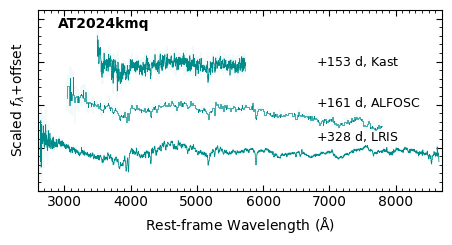

In [6]:
plot_source()